## Basic Setup

In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_history
from src.model_evaluation import evaluate_model
from src.plot_images import plot_images, plot_predictions, plot_false_positives, plot_false_negatives

In [6]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [7]:
model_name = '0_real_eyes'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [18]:
comment = "test123"
model_file_path = repo_path + f"/models/mlp/{model_name}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/mlp/{model_name}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/mlp/{model_name}/history/{comment}_history.csv"
# assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [9]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [10]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=30, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

In [11]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


## Training the Pre-Trained Model

In [13]:
def initialize_mlp_model(title, input_shape, dropout_rate):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(2, activation='softmax')
    ], name=title)
    
    # Compile the model
    model.compile(optimizer=OPTIMIZER, loss=LOSS_FUNCTION, metrics=['accuracy'])

    return model

In [14]:
# Build the model
model = initialize_mlp_model(title=model_name, input_shape=INPUT_SHAPE, dropout_rate=DROPOUT)

In [15]:
# Print model summary to verify
model.summary()

Model: "0_real_eyes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,267,970 (73.50 MB)

 Trainable params: 19,267,970 (73.50 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6094 - loss: 0.6628
Epoch 1: val_accuracy improved from -inf to 0.71613, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/0_real_eyes/ckpt/test123_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6105 - loss: 0.6617 - val_accuracy: 0.7161 - val_loss: 0.5567 - learning_rate: 1.0000e-04
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7209 - loss: 0.5506
Epoch 2: val_accuracy improved from 0.71613 to 0.74452, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/0_real_eyes/ckpt/test123_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - accuracy: 0.7212 - loss: 0.5503 - val_accuracy: 0.7445 - val_loss: 0.5229 - learning_rate: 1.0000e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7531 - loss: 0.5154
Epoch 3: val_accuracy improved from 0.74452 to 0.76000

In [19]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [21]:
# load the best model
model.load_weights(ckpt_file_path)

In [22]:
# save the model
model.save(model_file_path)

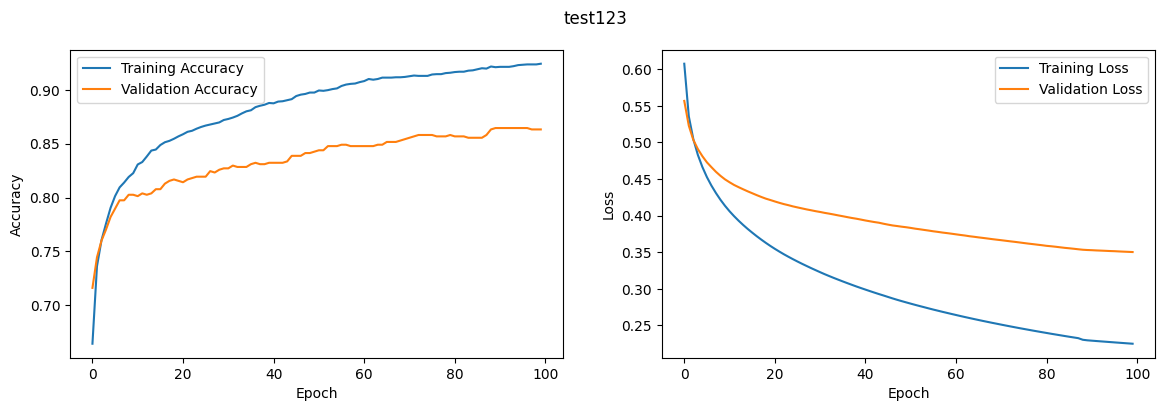

Best train_accuracy: 0.9242
Best train_loss: 0.2251
Best val_accuracy: 0.8645
Best val_loss: 0.3503
Last improvement at epoch: 90


In [23]:
plot_history(comment, history)

2024-07-16 22:08:05.217978: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test accuracy: 0.895
Test precision: 0.898
Test recall: 0.895
Test F1 score: 0.896
Prediction time: 4.19 seconds


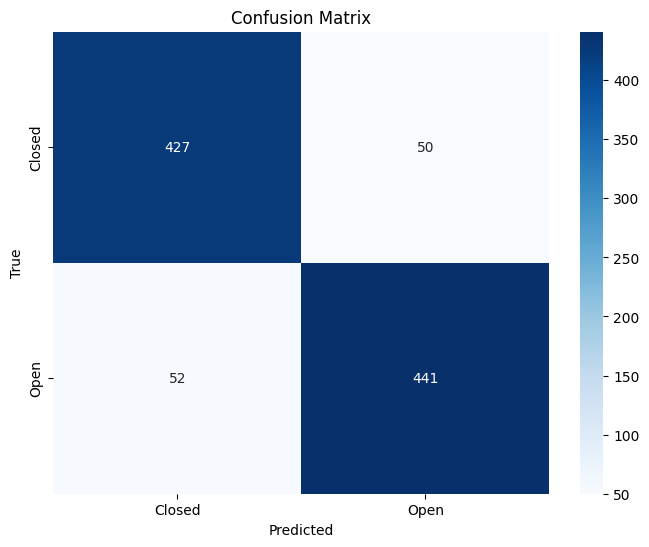

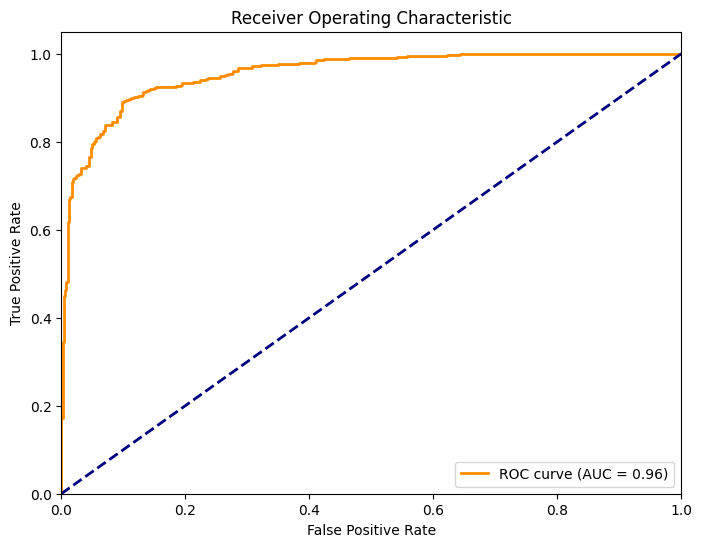

In [24]:
evaluate_model(model, real_test_data)